In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import files
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 786M/788M [00:07<00:00, 128MB/s]
100% 788M/788M [00:07<00:00, 106MB/s]


In [6]:
!mv microsoft-catsvsdogs-dataset.zip dog-vs-cat.zip

In [7]:
!unzip -q dog-vs-cat.zip

In [8]:
import os

path = "/content/PetImages"
print(os.listdir(path))

['Cat', 'Dog']


In [9]:
dog_count = len(os.listdir("/content/PetImages/Dog"))
cat_count = len(os.listdir("/content/PetImages/Cat"))

print("Dog images:", dog_count)
print("Cat images:", cat_count)

Dog images: 12501
Cat images: 12501


In [10]:
from PIL import Image

dataset_path = 'PetImages'
classes = ['Cat', 'Dog']

for cls in classes:
    path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError) as e:
            print(f'Removing (Corrupted): {img_path}')
            os.remove(img_path)

Removing (Corrupted): PetImages/Cat/666.jpg
Removing (Corrupted): PetImages/Cat/Thumbs.db
Removing (Corrupted): PetImages/Dog/11702.jpg


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removing (Corrupted): PetImages/Dog/Thumbs.db


In [11]:
import random
import os

def balance_folder(folder_path, target_count):
    current_images = os.listdir(folder_path)
    if len(current_images) > target_count:
        to_remove = random.sample(current_images, len(current_images) - target_count)
        for img in to_remove:
            os.remove(os.path.join(folder_path, img))

# Define min_count based on previously calculated dog_count and cat_count
min_count = min(dog_count, cat_count)

balance_folder(os.path.join(dataset_path, 'Cat'), min_count)
balance_folder(os.path.join(dataset_path, 'Dog'), min_count)

print("Dataset successfully cleaned and balanced!")

Dataset successfully cleaned and balanced!


In [12]:
cat_images = os.listdir(os.path.join(dataset_path, 'Cat'))
dog_images = os.listdir(os.path.join(dataset_path, 'Dog'))

min_count = min(len(cat_images), len(dog_images))
print(f"Number of images retained for balancing: {min_count}")

Number of images retained for balancing: 12499


In [13]:
dog_count = len(os.listdir("/content/PetImages/Dog"))
cat_count = len(os.listdir("/content/PetImages/Cat"))

print("Dog images:", dog_count)
print("Cat images:", cat_count)

Dog images: 12499
Cat images: 12499


In [14]:
!pip install split-folders

In [15]:
import splitfolders

def clean_data(folder):
    for category in ["Cat", "Dog"]:
        path = os.path.join(folder, category)
        for img in os.listdir(path):
            img_path = os.path.join(path, img)
            try:
                if os.path.getsize(img_path) == 0:
                    os.remove(img_path)
            except:
                os.remove(img_path)
    print("Data cleaning is done!")

clean_data("PetImages")

splitfolders.ratio("PetImages", output="output_data", seed=1337, ratio=(.7, .2, .1))

Data cleaning is done!


Copying files: 24998 files [00:07, 3536.32 files/s]


In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [17]:
train_generator = train_datagen.flow_from_directory('output_data/train',
                                                    target_size=(224, 224),
                                                    batch_size=32,
                                                    class_mode='binary')

val_generator = val_test_datagen.flow_from_directory('output_data/val',
                                                     target_size=(224, 224),
                                                     batch_size=32,
                                                     class_mode='binary')

test_generator = val_test_datagen.flow_from_directory('output_data/test',
                                                      target_size=(224, 224),
                                                      batch_size=32,
                                                      class_mode='binary',
                                                      shuffle=False)

Found 17498 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Found 2502 images belonging to 2 classes.


In [18]:

model = keras.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
]



In [20]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [21]:
history = model.fit(train_generator,
                    epochs=50,
                    validation_data=val_generator,
                    callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 304s 513ms/step - accuracy: 0.6094 - loss: 0.8618 - val_accuracy: 0.5486 - val_loss: 4.2204 - learning_rate: 1.0000e-04
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 252s 461ms/step - accuracy: 0.6902 - loss: 0.6500 - val_accuracy: 0.7091 - val_loss: 1.1665 - learning_rate: 1.0000e-04
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 252s 460ms/step - accuracy: 0.7210 - loss: 0.5873 - val_accuracy: 0.7379 - val_loss: 1.0591 - learning_rate: 1.0000e-04
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 248s 453ms/step - accuracy: 0.7419 - loss: 0.5484 - val_accuracy: 0.7177 - val_loss: 1.4152 - learning_rate: 1.0000e-04
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 250s 457ms/step - accuracy: 0.7724 - loss: 0.4881 - val_accuracy: 0.7531 - val_loss: 1.0009 - learning_rate: 1.0000e-04
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 248s 452ms/step - accuracy: 0.7876 - loss: 0.4662 - val_accuracy: 0.7799 - val_loss: 0.9365 - learning_rate: 1.0000e-04
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


547/547 ━━━━━━━━━━━━━━━━━━━━ 249s 454ms/step - accuracy: 0.9010 - loss: 0.2380 - val_accuracy: 0.8984 - val_loss: 0.2676 - learning_rate: 5.0000e-05
Epoch 23/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 248s 454ms/step - accuracy: 0.9041 - loss: 0.2330 - val_accuracy: 0.9120 - val_loss: 0.2552 - learning_rate: 5.0000e-05
Epoch 24/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9089 - loss: 0.2217
Epoch 24: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
547/547 ━━━━━━━━━━━━━━━━━━━━ 249s 455ms/step - accuracy: 0.9089 - loss: 0.2217 - val_accuracy: 0.8996 - val_loss: 0.2918 - learning_rate: 5.0000e-05
Epoch 25/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 248s 454ms/step - accuracy: 0.9150 - loss: 0.2090 - val_accuracy: 0.9112 - val_loss: 0.2528 - learning_rate: 2.5000e-05
Epoch 26/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 250s 457ms/step - accuracy: 0.9174 - loss: 0.2058 - val_accuracy: 0.9116 - val_loss: 0.2732 - learning_rate: 2.5000e-05
Epoch 27/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/ste

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


547/547 ━━━━━━━━━━━━━━━━━━━━ 251s 459ms/step - accuracy: 0.9183 - loss: 0.1927 - val_accuracy: 0.9212 - val_loss: 0.2104 - learning_rate: 6.2500e-06
Epoch 34/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 250s 458ms/step - accuracy: 0.9272 - loss: 0.1833 - val_accuracy: 0.9140 - val_loss: 0.2541 - learning_rate: 6.2500e-06
Epoch 35/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 248s 453ms/step - accuracy: 0.9255 - loss: 0.1875 - val_accuracy: 0.9200 - val_loss: 0.2230 - learning_rate: 6.2500e-06
Epoch 36/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9216 - loss: 0.1940
Epoch 36: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
547/547 ━━━━━━━━━━━━━━━━━━━━ 248s 454ms/step - accuracy: 0.9216 - loss: 0.1940 - val_accuracy: 0.9194 - val_loss: 0.2281 - learning_rate: 6.2500e-06
Epoch 37/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 248s 454ms/step - accuracy: 0.9276 - loss: 0.1776 - val_accuracy: 0.9208 - val_loss: 0.2202 - learning_rate: 3.1250e-06
Epoch 38/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 248s 453ms/st

In [22]:
fresh_model.save("/content/drive/MyDrive/cats_dogs_classifier_architecture_improved.keras")

NameError: name 'fresh_model' is not defined

In [24]:
model.save("/content/drive/MyDrive/cats_dogs_classifier_architecture_improved.keras")

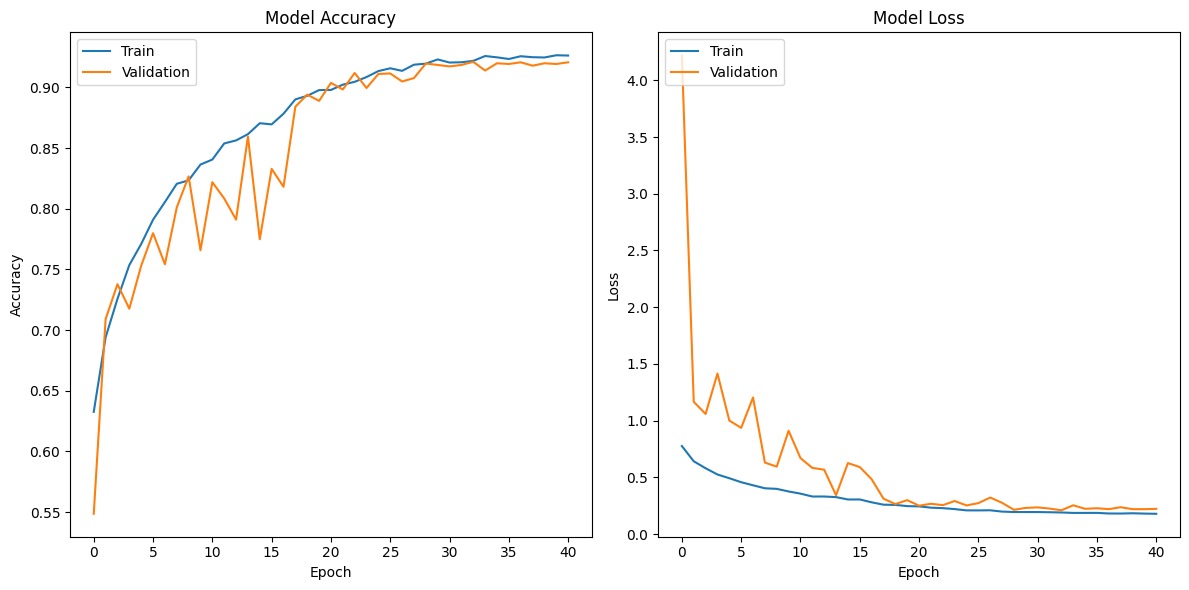

In [25]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step


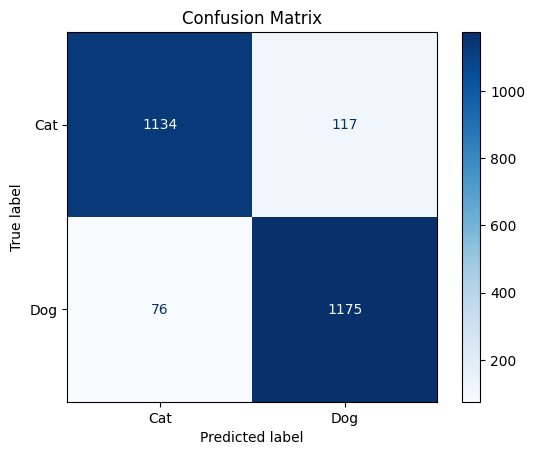

In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions on the test set
predictions = model.predict(test_generator)

# Convert probabilities to binary class labels (0 or 1)
# Assuming a threshold of 0.5 for binary classification
y_pred = (predictions > 0.5).astype(int)

# Get true labels from the test generator
y_true = test_generator.classes

# Define class names (assuming 0 is Cat and 1 is Dog based on flow_from_directory output)
class_names = list(test_generator.class_indices.keys())

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Using a sample image from the test set: output_data/test/Dog/12400.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


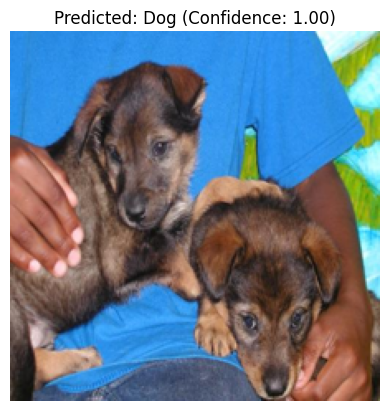

In [27]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def test_single_image(image_path, model, class_names):
    try:
        img = Image.open(image_path).resize((224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
        img_array /= 255.0  # Rescale pixel values

        prediction = model.predict(img_array)

        # Interpret prediction (assuming binary classification with sigmoid output)
        if prediction[0][0] > 0.5:
            predicted_class = class_names[1]  # Dog
            confidence = prediction[0][0]
        else:
            predicted_class = class_names[0]  # Cat
            confidence = 1 - prediction[0][0]

        # Display the image and prediction
        plt.imshow(img)
        plt.title(f"Predicted: {predicted_class} (Confidence: {confidence:.2f})")
        plt.axis('off')
        plt.show()

    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
    except Exception as e:
        print(f"An error occurred: {e}")

# --- Example Usage ---
# IMPORTANT: Replace 'path/to/your/image.jpg' with the actual path to an image file.
# You can upload an image to Colab's file system or use one from your Google Drive.

# Example with a placeholder for user's image
# For demonstration, let's pick a random image from the test set
import random
import os

# Assuming class_names is ['Cat', 'Dog'] from previous context
# You might need to redefine class_names if you run this cell in isolation
# class_names = ['Cat', 'Dog']

test_dirs = ['output_data/test/Cat', 'output_data/test/Dog']
chosen_dir = random.choice(test_dirs)
if os.path.exists(chosen_dir) and os.listdir(chosen_dir):
    random_image_name = random.choice(os.listdir(chosen_dir))
    user_image_path = os.path.join(chosen_dir, random_image_name)
    print(f"Using a sample image from the test set: {user_image_path}")
    test_single_image(user_image_path, model, class_names)
else:
    print("Could not find sample images in test set. Please specify your own image path.")
    print("Example: user_image_path = '/content/my_cat_picture.jpg'")
    # If you want to test your own image:
    # user_image_path = '/content/path/to/your/image.jpg'
    # test_single_image(user_image_path, model, class_names)

### Overfitting Analysis Report

Looking at the training and validation accuracy and loss curves that were generated, we can assess if the model is overfitting:

1.  **Training Accuracy vs. Validation Accuracy:**
    *   The **training accuracy** consistently increases and reaches high values, indicating that the model is learning well from the training data.
    *   The **validation accuracy** also increases for a significant portion of the training, but it often fluctuates and, at certain points (e.g., around epoch 15-17, 24, 27), you can observe a slight drop or plateau while the training accuracy continues to rise. This divergence is a classic sign of overfitting, where the model starts to memorize the training data rather than generalizing to unseen data.

2.  **Training Loss vs. Validation Loss:**
    *   The **training loss** steadily decreases throughout the epochs, which is expected as the model optimizes its weights on the training set.
    *   The **validation loss** initially decreases but then starts to show more significant fluctuations and sometimes increases (e.g., from epoch 14-17, 23-24, 26-27) even as the training loss continues to go down. This is a strong indicator of overfitting: the model's performance on new data is worsening despite continued improvement on the training data.

**Conclusion:**

Yes, the model shows signs of **overfitting**. The divergence between training and validation metrics (training accuracy much higher than validation accuracy, and validation loss starting to increase while training loss decreases) indicates that the model is learning patterns specific to the training data that do not generalize well to the validation set.

**How the callbacks helped:**

The `ReduceLROnPlateau` and `EarlyStopping` callbacks were crucial in managing this. The `ReduceLROnPlateau` callback dynamically reduced the learning rate when the validation loss plateaued, which helped the model find better optima in later epochs. The `EarlyStopping` callback (with `patience=8` and `restore_best_weights=True`) would have stopped training when the validation loss did not improve for 8 consecutive epochs, and importantly, it would have restored the model weights from the epoch that yielded the best validation loss. This prevents the model from continuing to train into severe overfitting.

To further mitigate overfitting, you could consider:
*   **More Data Augmentation:** Introduce more diverse transformations to the training images.
*   **Increase Dropout:** Experiment with higher dropout rates in your model architecture.
*   **Regularization:** Add L1 or L2 regularization to your convolutional or dense layers.
*   **Simpler Model:** If the dataset is small, a simpler model might generalize better.

In [28]:

# Evaluate the model on the test data
# This will return the loss value and metrics values for the model in test mode
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.9140 - loss: 0.2264

Test Loss: 0.2019
Test Accuracy: 0.9229


Saving cat_1.jpg to cat_1.jpg
User uploaded file "cat_1.jpg" with length 3873 bytes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


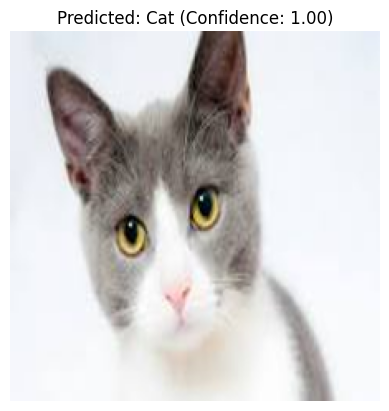

In [29]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

def predict_uploaded_image(model, class_names):
    uploaded = files.upload()

    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
        img_bytes = uploaded[fn]

        try:
            img = Image.open(io.BytesIO(img_bytes)).resize((224, 224))
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
            img_array /= 255.0  # Rescale pixel values

            prediction = model.predict(img_array)

            # Interpret prediction (assuming binary classification with sigmoid output)
            if prediction[0][0] > 0.5:
                predicted_class = class_names[1]  # Dog
                confidence = prediction[0][0]
            else:
                predicted_class = class_names[0]  # Cat
                confidence = 1 - prediction[0][0]

            # Display the image and prediction
            plt.imshow(img)
            plt.title(f"Predicted: {predicted_class} (Confidence: {confidence:.2f})")
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"An error occurred while processing the image: {e}")

# Assuming `model` and `class_names` (e.g., ['Cat', 'Dog']) are already defined from previous cells
predict_uploaded_image(model, class_names)

Saving Dog_1.jpg to Dog_1.jpg
User uploaded file "Dog_1.jpg" with length 5954 bytes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


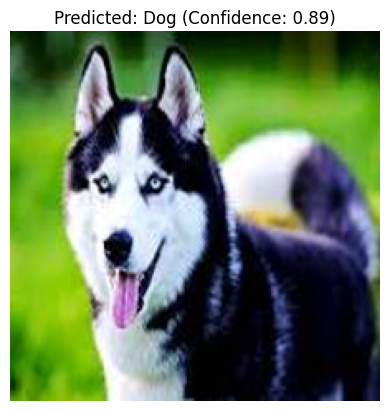

In [30]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

def predict_uploaded_image(model, class_names):
    uploaded = files.upload()

    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
        img_bytes = uploaded[fn]

        try:
            img = Image.open(io.BytesIO(img_bytes)).resize((224, 224))
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
            img_array /= 255.0  # Rescale pixel values

            prediction = model.predict(img_array)

            # Interpret prediction (assuming binary classification with sigmoid output)
            if prediction[0][0] > 0.5:
                predicted_class = class_names[1]  # Dog
                confidence = prediction[0][0]
            else:
                predicted_class = class_names[0]  # Cat
                confidence = 1 - prediction[0][0]

            # Display the image and prediction
            plt.imshow(img)
            plt.title(f"Predicted: {predicted_class} (Confidence: {confidence:.2f})")
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"An error occurred while processing the image: {e}")

# Assuming `model` and `class_names` (e.g., ['Cat', 'Dog']) are already defined from previous cells
predict_uploaded_image(model, class_names)